In [38]:
import pandas as pd



In [39]:
df = pd.read_csv('Final Project.csv')
df.head(15)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST00001,Male,0,No,Yes,3.0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,68.61,205.83,Yes
1,CUST00002,Male,1,Yes,No,2.0,Yes,Yes,DSL,No,...,No internet service,Yes,NaN,No,One year,Yes,Bank transfer (automatic),23.15,46.3,No
2,CUST00003,Female,No,No,No,42.0,Yes,Yes,DSL,No,...,No,NaN,Yes,Yes,Month-to-month,No,Electronic check,42.63,1790.46,Yes
3,CUST00004,Female,0,No,Yes,40.0,Yes,Yes,Fiber optic,No,...,Yes,No,No,No internet service,Month-to-month,No,Electronic check,75.04,3001.6,No
4,CUST00005,Male,Yes,Yes,Yes,17.0,Yes,NaN,Fiber optic,Yes,...,Yes,No,No internet service,No,Two year,Yes,Electronic check,22.38,380.46,Yes
5,CUST00006,Male,0,Yes,No,18.0,Yes,No,Fiber optic,No,...,NaN,Yes,NaN,No,One year,No,Electronic check,37.23,670.14,Yes
6,CUST00007,Female,0,No,No,25.0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,67.47,1686.75,No
7,CUST00008,Female,0,Yes,No,33.0,Yes,Yes,Fiber optic,No,...,No,No,No,NaN,Two year,No,Electronic check,76.30,2517.9,No
8,CUST00009,Female,0,Yes,No,6.0,Yes,Yes,DSL,Yes,...,No,No internet service,No,No internet service,Month-to-month,No,Electronic check,64.86,389.16,No
9,CUST00010,f,0,Yes,No,-5.0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Electronic check,18.60,0,Yes


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        70000 non-null  object 
 1   gender            69252 non-null  object 
 2   SeniorCitizen     69341 non-null  object 
 3   Partner           66470 non-null  object 
 4   Dependents        66435 non-null  object 
 5   tenure            69433 non-null  float64
 6   PhoneService      70000 non-null  object 
 7   MultipleLines     68132 non-null  object 
 8   InternetService   70000 non-null  object 
 9   OnlineSecurity    67078 non-null  object 
 10  OnlineBackup      67253 non-null  object 
 11  DeviceProtection  67106 non-null  object 
 12  TechSupport       67267 non-null  object 
 13  StreamingTV       67173 non-null  object 
 14  StreamingMovies   67215 non-null  object 
 15  Contract          70000 non-null  object 
 16  PaperlessBilling  70000 non-null  object

In [41]:
df.isnull().sum()

,0
customerID,0
gender,748
SeniorCitizen,659
Partner,3530
Dependents,3565
tenure,567
PhoneService,0
MultipleLines,1868
InternetService,0
OnlineSecurity,2922


In [42]:
df.duplicated().sum()

np.int64(0)

In [43]:
df.describe()

,tenure,MonthlyCharges
count,69433.000000,69612.000000
mean,30.516858,60.588548
std,89.873767,111.509588
min,-10.000000,18.000000
25%,10.000000,29.670000
50%,20.000000,41.190000
75%,35.000000,63.882500
max,999.000000,1499.770000


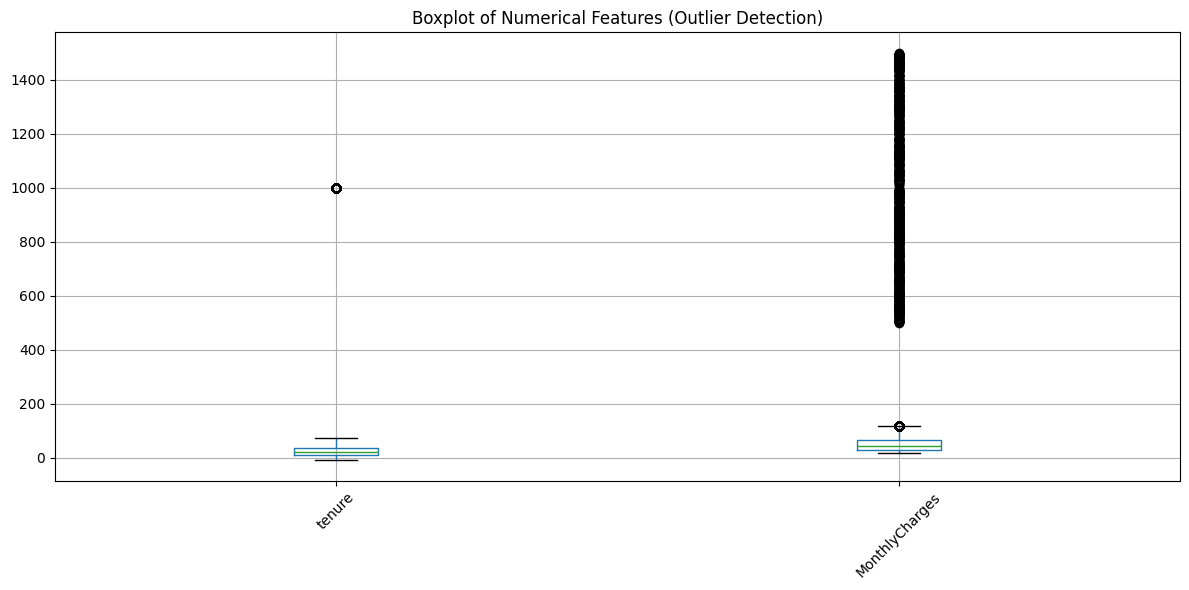

In [44]:
import matplotlib.pyplot as plt
import numpy as np

numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(12, 6))
df[numeric_cols].boxplot(rot=45)
plt.title("Boxplot of Numerical Features (Outlier Detection)")
plt.tight_layout()
plt.show()

In [45]:
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[cat_cols] = df[cat_cols].fillna('Unknown')
df[num_cols] = df[num_cols].fillna(df[num_cols].median())


In [46]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [47]:
df["SeniorCitizen"] = df["SeniorCitizen"].replace({"Yes":1,"No":0})
df["SeniorCitizen"] = pd.to_numeric(df["SeniorCitizen"], errors= "coerce")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors= "coerce")
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST00001,Male,0.0,No,Yes,3.0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,68.61,205.83,Yes
1,CUST00002,Male,1.0,Yes,No,2.0,Yes,Yes,DSL,No,...,No internet service,Yes,Unknown,No,One year,Yes,Bank transfer (automatic),23.15,46.30,No
2,CUST00003,Female,0.0,No,No,42.0,Yes,Yes,DSL,No,...,No,Unknown,Yes,Yes,Month-to-month,No,Electronic check,42.63,1790.46,Yes
3,CUST00004,Female,0.0,No,Yes,40.0,Yes,Yes,Fiber optic,No,...,Yes,No,No,No internet service,Month-to-month,No,Electronic check,75.04,3001.60,No
4,CUST00005,Male,1.0,Yes,Yes,17.0,Yes,Unknown,Fiber optic,Yes,...,Yes,No,No internet service,No,Two year,Yes,Electronic check,22.38,380.46,Yes
5,CUST00006,Male,0.0,Yes,No,18.0,Yes,No,Fiber optic,No,...,Unknown,Yes,Unknown,No,One year,No,Electronic check,37.23,670.14,Yes
6,CUST00007,Female,0.0,No,No,25.0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,67.47,1686.75,No
7,CUST00008,Female,0.0,Yes,No,33.0,Yes,Yes,Fiber optic,No,...,No,No,No,Unknown,Two year,No,Electronic check,76.30,2517.90,No
8,CUST00009,Female,0.0,Yes,No,6.0,Yes,Yes,DSL,Yes,...,No,No internet service,No,No internet service,Month-to-month,No,Electronic check,64.86,389.16,No
9,CUST00010,f,0.0,Yes,No,-5.0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Electronic check,18.60,0.00,Yes


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        70000 non-null  object 
 1   gender            70000 non-null  object 
 2   SeniorCitizen     69091 non-null  float64
 3   Partner           70000 non-null  object 
 4   Dependents        70000 non-null  object 
 5   tenure            70000 non-null  float64
 6   PhoneService      70000 non-null  object 
 7   MultipleLines     70000 non-null  object 
 8   InternetService   70000 non-null  object 
 9   OnlineSecurity    70000 non-null  object 
 10  OnlineBackup      70000 non-null  object 
 11  DeviceProtection  70000 non-null  object 
 12  TechSupport       70000 non-null  object 
 13  StreamingTV       70000 non-null  object 
 14  StreamingMovies   70000 non-null  object 
 15  Contract          70000 non-null  object 
 16  PaperlessBilling  70000 non-null  object

In [49]:
service_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies']
df[service_cols] = df[service_cols].replace({'No internet service':'No'})
df.head(15)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST00001,Male,0.0,No,Yes,3.0,Yes,Yes,No,No,...,No,No,No,No,Month-to-month,No,Mailed check,68.61,205.83,Yes
1,CUST00002,Male,1.0,Yes,No,2.0,Yes,Yes,DSL,No,...,No,Yes,Unknown,No,One year,Yes,Bank transfer (automatic),23.15,46.30,No
2,CUST00003,Female,0.0,No,No,42.0,Yes,Yes,DSL,No,...,No,Unknown,Yes,Yes,Month-to-month,No,Electronic check,42.63,1790.46,Yes
3,CUST00004,Female,0.0,No,Yes,40.0,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,No,Electronic check,75.04,3001.60,No
4,CUST00005,Male,1.0,Yes,Yes,17.0,Yes,Unknown,Fiber optic,Yes,...,Yes,No,No,No,Two year,Yes,Electronic check,22.38,380.46,Yes
5,CUST00006,Male,0.0,Yes,No,18.0,Yes,No,Fiber optic,No,...,Unknown,Yes,Unknown,No,One year,No,Electronic check,37.23,670.14,Yes
6,CUST00007,Female,0.0,No,No,25.0,Yes,Yes,No,No,...,No,No,No,No,One year,Yes,Mailed check,67.47,1686.75,No
7,CUST00008,Female,0.0,Yes,No,33.0,Yes,Yes,Fiber optic,No,...,No,No,No,Unknown,Two year,No,Electronic check,76.30,2517.90,No
8,CUST00009,Female,0.0,Yes,No,6.0,Yes,Yes,DSL,Yes,...,No,No,No,No,Month-to-month,No,Electronic check,64.86,389.16,No
9,CUST00010,f,0.0,Yes,No,-5.0,Yes,No,No,No,...,No,No,No,No,Month-to-month,No,Electronic check,18.60,0.00,Yes


In [50]:
df['gender'] = df['gender'].replace({'f':"Female", 'm':"Male"})
df.head(15)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST00001,Male,0.0,No,Yes,3.0,Yes,Yes,No,No,...,No,No,No,No,Month-to-month,No,Mailed check,68.61,205.83,Yes
1,CUST00002,Male,1.0,Yes,No,2.0,Yes,Yes,DSL,No,...,No,Yes,Unknown,No,One year,Yes,Bank transfer (automatic),23.15,46.30,No
2,CUST00003,Female,0.0,No,No,42.0,Yes,Yes,DSL,No,...,No,Unknown,Yes,Yes,Month-to-month,No,Electronic check,42.63,1790.46,Yes
3,CUST00004,Female,0.0,No,Yes,40.0,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,No,Electronic check,75.04,3001.60,No
4,CUST00005,Male,1.0,Yes,Yes,17.0,Yes,Unknown,Fiber optic,Yes,...,Yes,No,No,No,Two year,Yes,Electronic check,22.38,380.46,Yes
5,CUST00006,Male,0.0,Yes,No,18.0,Yes,No,Fiber optic,No,...,Unknown,Yes,Unknown,No,One year,No,Electronic check,37.23,670.14,Yes
6,CUST00007,Female,0.0,No,No,25.0,Yes,Yes,No,No,...,No,No,No,No,One year,Yes,Mailed check,67.47,1686.75,No
7,CUST00008,Female,0.0,Yes,No,33.0,Yes,Yes,Fiber optic,No,...,No,No,No,Unknown,Two year,No,Electronic check,76.30,2517.90,No
8,CUST00009,Female,0.0,Yes,No,6.0,Yes,Yes,DSL,Yes,...,No,No,No,No,Month-to-month,No,Electronic check,64.86,389.16,No
9,CUST00010,Female,0.0,Yes,No,-5.0,Yes,No,No,No,...,No,No,No,No,Month-to-month,No,Electronic check,18.60,0.00,Yes


In [51]:
df["Churn"] = df["Churn"].map({"Yes":1,"No":0})
df.head(15)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST00001,Male,0.0,No,Yes,3.0,Yes,Yes,No,No,...,No,No,No,No,Month-to-month,No,Mailed check,68.61,205.83,1.0
1,CUST00002,Male,1.0,Yes,No,2.0,Yes,Yes,DSL,No,...,No,Yes,Unknown,No,One year,Yes,Bank transfer (automatic),23.15,46.30,0.0
2,CUST00003,Female,0.0,No,No,42.0,Yes,Yes,DSL,No,...,No,Unknown,Yes,Yes,Month-to-month,No,Electronic check,42.63,1790.46,1.0
3,CUST00004,Female,0.0,No,Yes,40.0,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,No,Electronic check,75.04,3001.60,0.0
4,CUST00005,Male,1.0,Yes,Yes,17.0,Yes,Unknown,Fiber optic,Yes,...,Yes,No,No,No,Two year,Yes,Electronic check,22.38,380.46,1.0
5,CUST00006,Male,0.0,Yes,No,18.0,Yes,No,Fiber optic,No,...,Unknown,Yes,Unknown,No,One year,No,Electronic check,37.23,670.14,1.0
6,CUST00007,Female,0.0,No,No,25.0,Yes,Yes,No,No,...,No,No,No,No,One year,Yes,Mailed check,67.47,1686.75,0.0
7,CUST00008,Female,0.0,Yes,No,33.0,Yes,Yes,Fiber optic,No,...,No,No,No,Unknown,Two year,No,Electronic check,76.30,2517.90,0.0
8,CUST00009,Female,0.0,Yes,No,6.0,Yes,Yes,DSL,Yes,...,No,No,No,No,Month-to-month,No,Electronic check,64.86,389.16,0.0
9,CUST00010,Female,0.0,Yes,No,-5.0,Yes,No,No,No,...,No,No,No,No,Month-to-month,No,Electronic check,18.60,0.00,1.0


In [52]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,909
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        70000 non-null  object 
 1   gender            70000 non-null  object 
 2   SeniorCitizen     69091 non-null  float64
 3   Partner           70000 non-null  object 
 4   Dependents        70000 non-null  object 
 5   tenure            70000 non-null  float64
 6   PhoneService      70000 non-null  object 
 7   MultipleLines     70000 non-null  object 
 8   InternetService   70000 non-null  object 
 9   OnlineSecurity    70000 non-null  object 
 10  OnlineBackup      70000 non-null  object 
 11  DeviceProtection  70000 non-null  object 
 12  TechSupport       70000 non-null  object 
 13  StreamingTV       70000 non-null  object 
 14  StreamingMovies   70000 non-null  object 
 15  Contract          70000 non-null  object 
 16  PaperlessBilling  70000 non-null  object

In [54]:
df[["SeniorCitizen","TotalCharges"]] = df[["SeniorCitizen","TotalCharges"]].fillna(df[["SeniorCitizen","TotalCharges"]].median())
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [55]:
df = df.dropna(subset=['Churn'])
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [56]:
df['Churn'].value_counts()

,count
Churn,
0.0,37057
1.0,32713


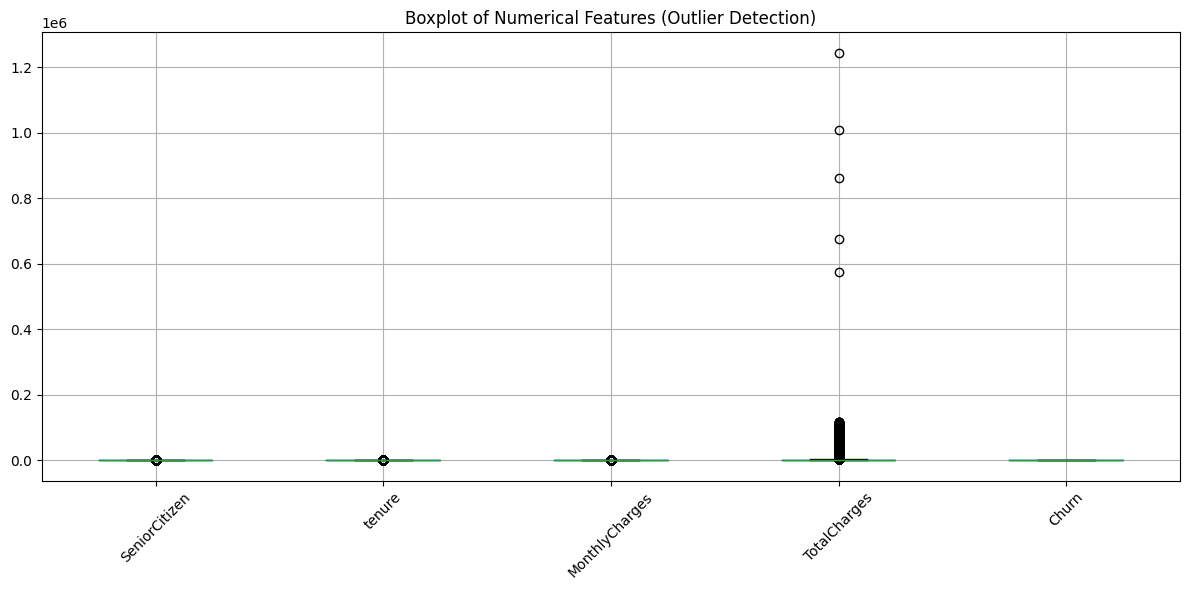

In [58]:
numeric_cols2 = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(12, 6))
df[numeric_cols2].boxplot(rot=45)
plt.title("Boxplot of Numerical Features (Outlier Detection)")
plt.tight_layout()
plt.show()

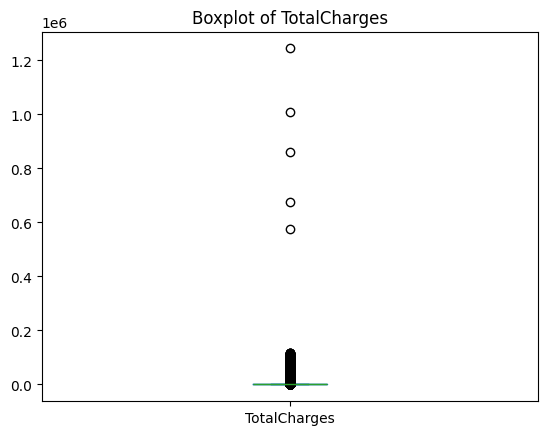

In [59]:
df["TotalCharges"].plot(kind='box', title='Boxplot of TotalCharges')
plt.show()

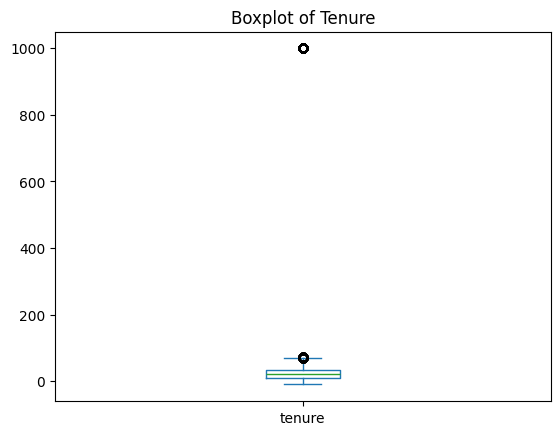

In [60]:
df["tenure"].plot(kind='box', title='Boxplot of Tenure')
plt.show()

In [61]:
df[['tenure',"TotalCharges"]].describe()

,tenure,TotalCharges
count,69770.000000,6.977000e+04
mean,30.429110,1.745152e+03
std,89.505011,9.481079e+03
min,-10.000000,-9.912000e+01
25%,10.000000,4.059925e+02
50%,20.000000,8.209700e+02
75%,34.000000,1.470467e+03
max,999.000000,1.244434e+06


In [62]:
df['tenure'] = df['tenure'].abs()
df['tenure'] = df['tenure'].replace(999, np.nan)

In [63]:
df.loc[df['TotalCharges'] < 0, 'TotalCharges'] = np.nan

In [64]:
df = df.dropna(subset=['tenure', 'TotalCharges'])

In [65]:
df[['tenure',"TotalCharges"]].describe()

,tenure,TotalCharges
count,69000.000000,69000.000000
mean,22.661971,1325.371630
std,15.277303,3070.638004
min,1.000000,0.000000
25%,10.000000,406.080000
50%,20.000000,820.970000
75%,34.000000,1449.140000
max,72.000000,104547.100000


In [66]:
df.to_csv('Final_Project_Cleaned.csv', index=False)